In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
import json
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import itertools
import time
import matplotlib.pyplot as plt

import models
from processdata import TimeSeriesDataset

In [16]:
# Define os caminhos de salvamento e carregamento
save_path = r"./results/csshred/sst"
load_path = r"./results/csshred/sst"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")


In [19]:
def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_plot=False, save_path=None, file_prefix="plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundos
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_training_error.png")
        plt.savefig(save_file)
        print(f"Training error plot saved to {save_file}")
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_validation_error.png")
        plt.savefig(save_file)
        print(f"Validation error plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Original - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(test_ground_truth[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Original - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_original.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Original plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Subsampled - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(subsampled[:, :, -1], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Subsampled - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_subsampled.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Subsampled plot saved to {save_file}")
    plt.show()

    # Calculate SSIM
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM for the last snapshot: {ssim_value}")

    # Save SSIM value to JSON
    if save_plot:
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, 'w') as f:
            json.dump({'SSIM': float(ssim_value)}, f)
        print(f"SSIM value saved to {ssim_file}")

    plt.show()


plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_plot=True, save_path=save_path, file_prefix="plot"
)



NameError: name 'train_error' is not defined

Plot saved to ./results/shred/sst/humidity_analysis_reconstructed_last_snapshot.png


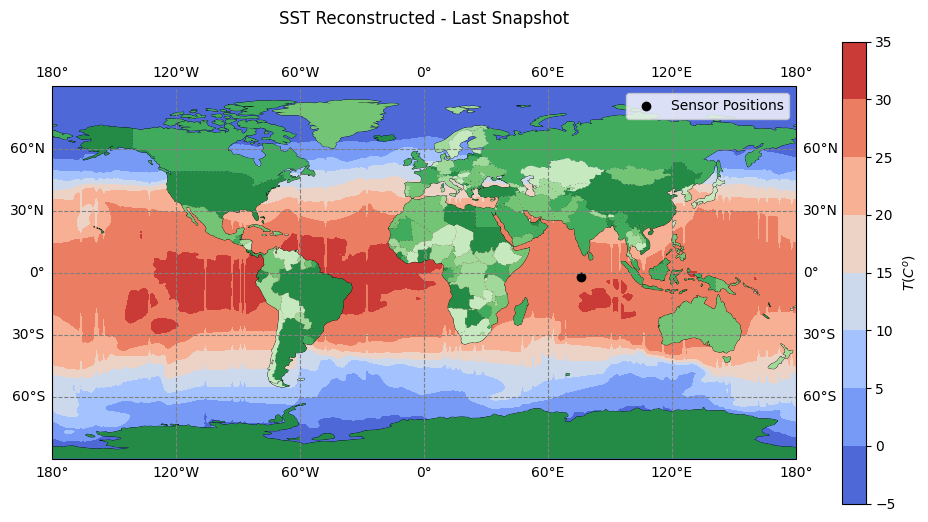

Plot saved to ./results/shred/sst/humidity_analysis_original_last_snapshot.png


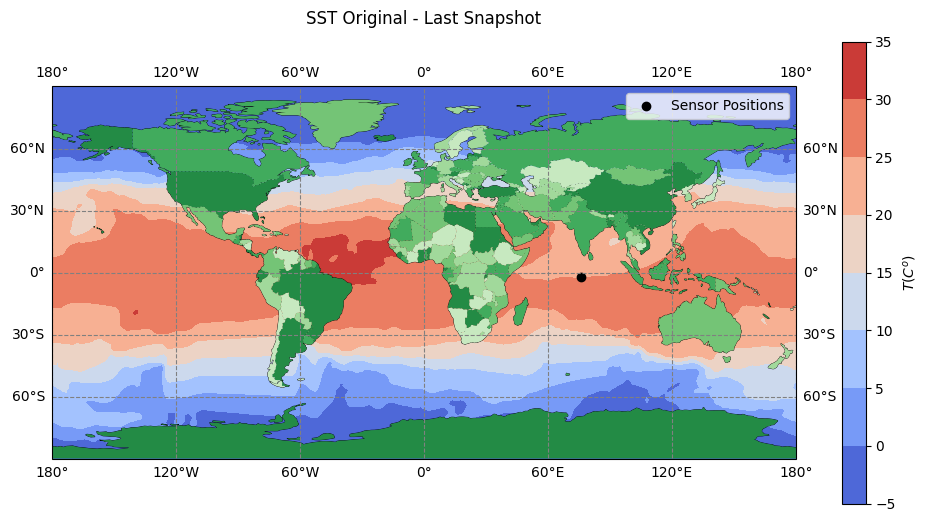

Plot saved to ./results/shred/sst/humidity_analysis_subsampled_last_snapshot.png


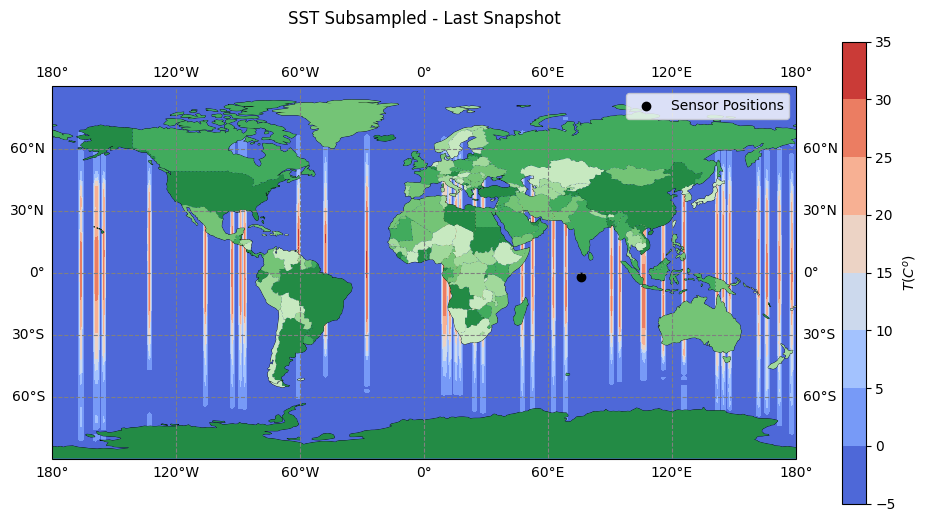

SSIM of SST - last snapshot: 0.8000848925378854
SSIM value saved to ./results/shred/sst/humidity_analysis_ssim.json
Plot saved to ./results/shred/sst/humidity_analysis_high_humidity_areas.png


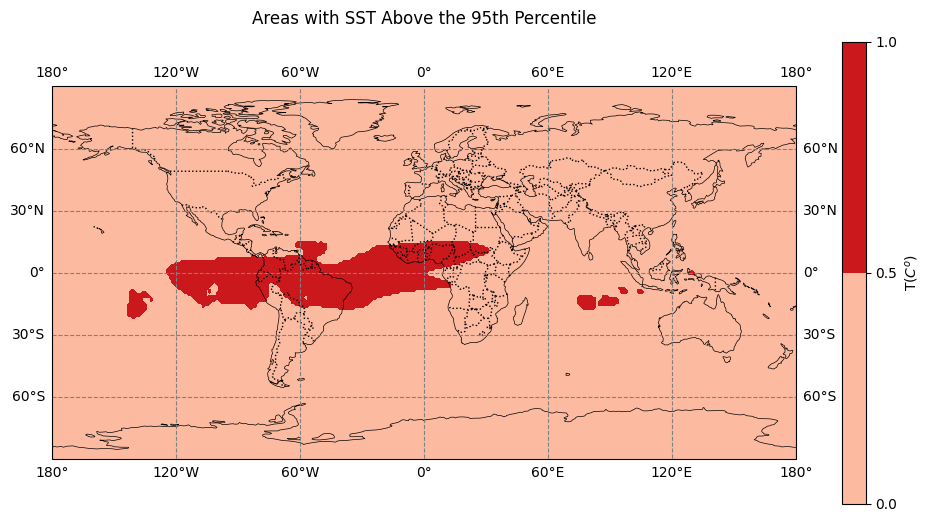

Plot saved to ./results/shred/sst/humidity_analysis_sst.png


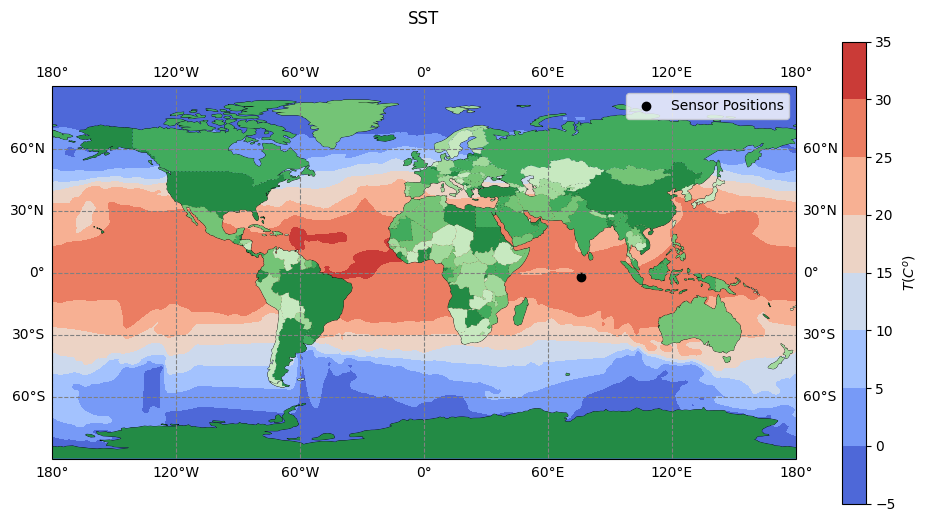

In [20]:

def plot_with_map(
    data, title, label, sensor_positions_x, sensor_positions_y, 
    save_path=None, file_name=None
):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, data.shape[1]),
        np.linspace(-90, 90, data.shape[0]),
        data,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Ajustar as coordenadas dos sensores para o sistema de referência geográfica
    sensor_lon = sensor_positions_x * 360 - 180  # Converter de [0,1] para [-180,180]
    sensor_lat = sensor_positions_y * 180 - 90  # Converter de [0,1] para [-90,90]

    ax.scatter(sensor_lon, sensor_lat, color="k", label="Sensor Positions")
    ax.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo

    # Carregar shapefile de países
    shapename = "admin_0_countries"
    countries_shp = shpreader.natural_earth(
        resolution="110m", category="cultural", name=shapename
    )

    # Definir cores "terrosas"
    earth_colors = (
        np.array(
            [
                (199, 233, 192),
                (161, 217, 155),
                (116, 196, 118),
                (65, 171, 93),
                (35, 139, 69),
            ]
        )
        / 255.0
    )
    earth_colors = itertools.cycle(earth_colors)

    # Adicionar geometria dos países ao mapa
    for country in shpreader.Reader(countries_shp).records():
        ax.add_geometries(
            country.geometry,
            ccrs.PlateCarree(),
            facecolor=next(earth_colors),
            label=country.attributes["NAME"],
        )

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label(label)
    plt.title(title, pad=30)

    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.png")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_high_humidity_areas(mean_qmax, title, save_path=None, file_name=None):
    high_qmax_areas = mean_qmax > np.percentile(mean_qmax, 95)  # Áreas com umidade específica máxima no maior percentil 5%
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Criar mapa de contorno preenchido
    c = ax.contourf(
        np.linspace(-180, 180, high_qmax_areas.shape[1]),
        np.linspace(-90, 90, high_qmax_areas.shape[0]),
        high_qmax_areas,
        transform=ccrs.PlateCarree(),
        cmap="Reds",
    )

    # Adicionar feições de terra com preenchimento cinza
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

    # Adicionar barra de cores
    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label('T$(C^o)$')
    plt.title(title, pad=30)
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    
    if save_path and file_name:
        save_file = os.path.join(save_path, f"{file_name}.png")
        plt.savefig(save_file)
        print(f"Plot saved to {save_file}")

    plt.show()

def plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    subsampled,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=None,
    file_prefix="cartografy_plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot 3: Reconstruído - Última Imagem com Continentes
    plot_with_map(
        test_recons[-1, :, :],
        "SST Reconstructed - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_reconstructed_last_snapshot"
    )

    # Plot 4: Original - Última Imagem com Continentes (Teste)
    plot_with_map(
        test_ground_truth[-1, :, :],
        "SST Original - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_original_last_snapshot"
    )

    # Plot 5: Subamostrado - Última Imagem com Continentes
    plot_with_map(
        subsampled[:, :, -1],
        "SST Subsampled - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_subsampled_last_snapshot"
    )

    # Calcular e imprimir o SSIM para a última imagem
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM of SST - last snapshot: {ssim_value}")

    if save_plot and save_path is not None:
        ssim_data = {"ssim_value": ssim_value}
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, "w") as f:
            json.dump(ssim_data, f)
        print(f"SSIM value saved to {ssim_file}")

    # Plotar áreas com alta umidade específica
    mean_qmax = np.mean(matrix, axis=0)
    plot_high_humidity_areas(
        mean_qmax, 
        'Areas with SST Above the 95th Percentile',
        save_path=save_path,
        file_name=f"{file_prefix}_high_humidity_areas"
    )

    sst = matrix[-1, :, :]
    plot_with_map(
        sst,
        "SST",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        save_path=save_path,
        file_name=f"{file_prefix}_sst"
    )

plot_results_cartografy(
    test_recons,
    test_ground_truth,
    matrix,
    snapshot,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=save_path,  
    file_prefix='humidity_analysis' 
)



test_recons (169, 180, 360)
test_ground_truth (169, 180, 360)


/tmp/ipykernel_8433/2068833163.py:79: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


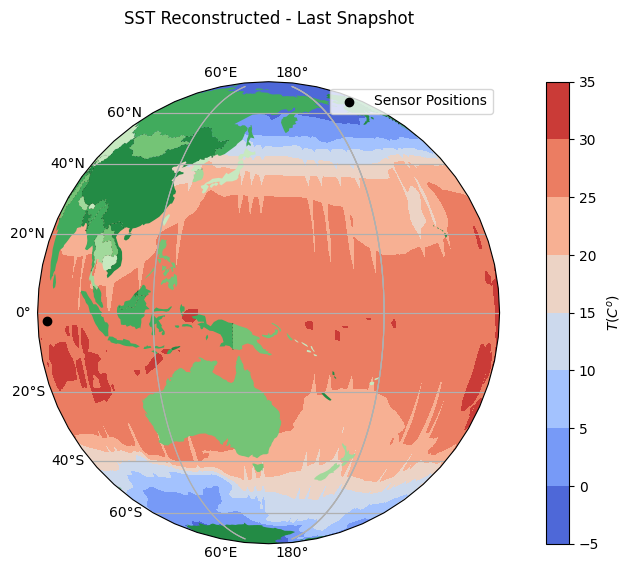

/tmp/ipykernel_8433/2068833163.py:79: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


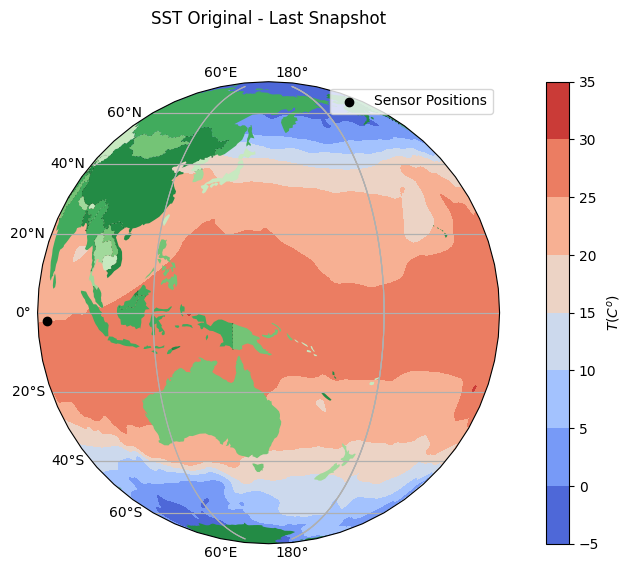

/tmp/ipykernel_8433/2068833163.py:79: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


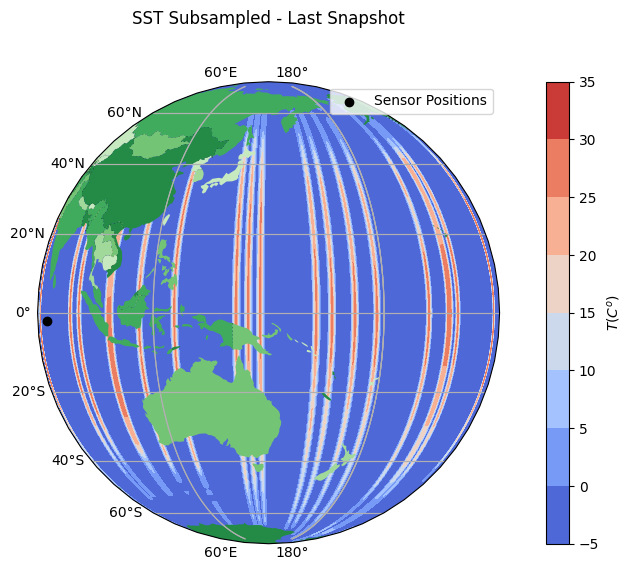

Mean SSIM: 0.7296220162507049
Mean PSNR: 21.639409260604552 dB
Mean NPS: 521601.9252267083
Mean MSE: 8.049412727355957
Last snapshot SSIM: 0.7892508359423739
Last snapshot PSNR: 23.347952420437643 dB
Last snapshot NPS: 300280.57722451165
Last snapshot MSE: 4.6339592933654785
Results saved to ./results/shred/sst/humidity_analysis_globe_results.json


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import itertools
import json
import os
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
from math import log10

def calculate_nps(img1, img2):
    noise = img1 - img2
    ft = np.fft.fft2(noise)
    nps = np.abs(ft)**2
    return nps

# Função para plotar dados com mapa de contorno em uma determinada projeção
def plot_with_map_projection(
    data, title, label, sensor_positions_x, sensor_positions_y, projection=ccrs.PlateCarree(), save_plot=False, save_path=save_path, file_prefix='humidity_analysis_globe'
):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=projection)
    c = ax.contourf(
        np.linspace(-180, 180, data.shape[1]),
        np.linspace(-90, 90, data.shape[0]),
        data,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
    )
    # Configurações adicionais do mapa
    ax.set_global()
    ax.gridlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=1)

    # Carregar shapefile de países
    shapename = "admin_0_countries"
    countries_shp = shpreader.natural_earth(
        resolution="110m", category="cultural", name=shapename
    )

    # Definir cores "terrosas"
    earth_colors = (
        np.array(
            [
                (199, 233, 192),
                (161, 217, 155),
                (116, 196, 118),
                (65, 171, 93),
                (35, 139, 69),
            ]
        )
        / 255.0
    )
    earth_colors = itertools.cycle(earth_colors)

    # Adicionar geometria dos países ao mapa
    for country in shpreader.Reader(countries_shp).records():
        ax.add_geometries(
            country.geometry,
            ccrs.PlateCarree(),
            facecolor=next(earth_colors),
            label=country.attributes["NAME"],
        )
    ax.gridlines(draw_labels=True)

    # Ajustar as coordenadas dos sensores para o sistema de referência geográfica
    sensor_lon = sensor_positions_x * 360 - 180  # Converter de [0,1] para [-180,180]
    sensor_lat = sensor_positions_y * 180 - 90  # Converter de [0,1] para [-90,90]

    ax.scatter(
        sensor_lon,
        sensor_lat,
        color="k",
        label="Sensor Positions",
        transform=ccrs.PlateCarree(),
    )
    ax.legend()

    cbar = plt.colorbar(c, ax=ax, orientation="vertical")
    cbar.set_label(label)
    plt.title(title, pad=30)

    if save_plot:
        plt.savefig(f"{save_path}/{file_prefix}_{title.replace(' ', '_')}.png")

    plt.show()

# Função para plotar os resultados
def plot_results(
    test_recons,
    test_ground_truth,
    matrix,
    subsampled,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=False,
    save_path='',
    file_prefix=''
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)

    # Plot 3: Reconstructed - Last Snapshot with Orthographic Projection
    sst_recons = test_recons[-1, :, :]
    plot_with_map_projection(
        sst_recons,
        "SST Reconstructed - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        projection=ccrs.Orthographic(central_longitude=150, central_latitude=0),
        save_plot=save_plot,
        save_path=save_path,
        file_prefix=file_prefix
    )

    # Plot 4: Original - Last Snapshot with Orthographic Projection (Test)
    sst_original = test_ground_truth[-1, :, :]
    plot_with_map_projection(
        sst_original,
        "SST Original - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        projection=ccrs.Orthographic(central_longitude=150, central_latitude=0),
        save_plot=save_plot,
        save_path=save_path,
        file_prefix=file_prefix
    )

    # Plot 5: Subsampled - Last Snapshot with Orthographic Projection
    sst_subsampled = subsampled[:, :, -1]
    plot_with_map_projection(
        sst_subsampled,
        "SST Subsampled - Last Snapshot",
        "$T(C^o)$",
        sensor_positions_x,
        sensor_positions_y,
        projection=ccrs.Orthographic(central_longitude=150, central_latitude=0),
        save_plot=save_plot,
        save_path=save_path,
        file_prefix=file_prefix
    )

    ssim_values = []
    psnr_values = []
    nps_values = []
    mse_values = []
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[i, :, :],
            test_recons[i, :, :],
            data_range=test_ground_truth[i, :, :].max() - test_ground_truth[i, :, :].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[i, :, :], test_recons[i, :, :])
        mse_values.append(mse)
        
        max_pixel = np.max(test_ground_truth[i, :, :])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)
        
        nps = calculate_nps(test_ground_truth[i, :, :], test_recons[i, :, :])
        nps_values.append(np.mean(nps))

    # Calculando médias
    mean_ssim = np.mean(ssim_values)
    mean_psnr = np.mean(psnr_values)
    mean_nps = np.mean(nps_values)
    mean_mse = np.mean(mse_values)

    # Calculando métricas para o último snapshot
    last_ssim = ssim_values[-1]
    last_psnr = psnr_values[-1]
    last_nps = nps_values[-1]
    last_mse = mse_values[-1]

    print(f"Mean SSIM: {mean_ssim}")
    print(f"Mean PSNR: {mean_psnr} dB")
    print(f"Mean NPS: {mean_nps}")
    print(f"Mean MSE: {mean_mse}")
    print(f"Last snapshot SSIM: {last_ssim}")
    print(f"Last snapshot PSNR: {last_psnr} dB")
    print(f"Last snapshot NPS: {last_nps}")
    print(f"Last snapshot MSE: {last_mse}")

    if save_plot:
        results = {
            'Mean_SSIM': float(mean_ssim),
            'Mean_PSNR': float(mean_psnr),
            'Mean_NPS': float(mean_nps),
            'Mean_MSE': float(mean_mse),
            'Last_SSIM': float(last_ssim),
            'Last_PSNR': float(last_psnr),
            'Last_NPS': float(last_nps),
            'Last_MSE': float(last_mse)
        }
        with open(f'{save_path}/{file_prefix}_results.json', 'w') as json_file:
            json.dump(results, json_file, indent=4)
        print(f"Results saved to {save_path}/{file_prefix}_results.json")

plot_results(
    test_recons,
    test_ground_truth,
    matrix,
    snapshot,
    sensor_positions_x,
    sensor_positions_y,
    save_plot=True,
    save_path=save_path,  
    file_prefix='humidity_analysis_globe'  
)

In [14]:
import lpips
import json
import os

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)  # ou 'vgg'

# Convertendo imagens para tensores e normalizando
img0 = torch.from_numpy(test_ground_truth).unsqueeze(0).float()  # Ground truth
img1 = torch.from_numpy(test_recons).unsqueeze(0).float()  # Reconstructed

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

lpips_value = d.item()
print(f'LPIPS (perceptual loss): {lpips_value}')

# Carregando o arquivo JSON existente
json_file_path = os.path.join(save_path, "plot_ssim.json")
with open(json_file_path, "r") as json_file:
    results = json.load(json_file)

# Adicionando a métrica LPIPS aos resultados
results["LPIPS"] = lpips_value

# Salvando o arquivo JSON atualizado
with open(json_file_path, "w") as json_file:
    json.dump(results, json_file, indent=4)

print(f"Resultados atualizados com LPIPS salvos em {json_file_path}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS (perceptual loss): 0.24839147925376892
Resultados atualizados com LPIPS salvos em ./results/shred/sst/plot_ssim.json
